In [1]:
from nsga2 import Nsga2
import pickle
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

In [2]:
nsga = Nsga2(generations=800, generator_population_size=200, cross_type=2)
nsga.run()
filename = "data/history/" + datetime.now().strftime("%Y-%m-%d--%H:%M:%S") + ".pkl"
pickle.dump(nsga.pareto_history, open(filename, 'wb'))

In [3]:
rank0 = nsga.get_pareto_front()
rank0.sort(key=lambda solution: solution.fitness[2])
print("Numero de soluciones en el frente de pareto:", len(rank0), "\n")
for solution in rank0:
    print(solution.fitness)

Numero de soluciones en el frente de pareto: 144 

(0.0, 0.0, 1)
(0.0, 0.0, 1)
(0.0, 0.0, 1)
(0.0, 0.0, 1)
(0.265625, 0.0, 3)
(0.5723076923076923, 0.0, 4)
(0.5087108013937283, 0.1941747572815534, 4)
(0.6190476190476191, 0.1782178217821782, 5)
(0.5650793650793651, 0.25, 5)
(0.6211180124223602, 0.26666666666666666, 6)
(0.5607476635514018, 0.36036036036036034, 6)
(0.6130030959752322, 0.2857142857142857, 7)
(0.6529411764705882, 0.14, 8)
(0.641399416909621, 0.2830188679245283, 8)
(0.6282420749279539, 0.34234234234234234, 8)
(0.6144578313253012, 0.3486238532110092, 8)
(0.49838187702265374, 0.36363636363636365, 8)
(0.6369047619047619, 0.34234234234234234, 9)
(0.608955223880597, 0.375, 9)
(0.5283018867924528, 0.3783783783783784, 9)
(0.6449704142011834, 0.36036036036036034, 10)
(0.5953757225433526, 0.3826086956521739, 10)
(0.5791044776119403, 0.38596491228070173, 10)
(0.5686900958466453, 0.41739130434782606, 10)
(0.6569767441860465, 0.2641509433962264, 11)
(0.656891495601173, 0.4210526315789473

In [4]:
rank0.sort(key=lambda solution: (solution.fitness[0] + solution.fitness[1])/2, reverse=True)
for solution in rank0:
    print(solution.fitness)

(0.6762177650429799, 0.6165413533834586, 50)
(0.6608695652173913, 0.6212121212121212, 50)
(0.6820809248554913, 0.6, 34)
(0.6763848396501457, 0.6015037593984962, 42)
(0.6938775510204082, 0.578125, 46)
(0.7082152974504249, 0.5555555555555556, 50)
(0.7163323782234957, 0.544, 50)
(0.7028571428571428, 0.5555555555555556, 43)
(0.7093023255813954, 0.5483870967741935, 48)
(0.6528189910979229, 0.6046511627906976, 49)
(0.6857142857142857, 0.5669291338582677, 43)
(0.6887052341597796, 0.56, 40)
(0.7272727272727273, 0.5203252032520326, 50)
(0.6392961876832844, 0.6074074074074074, 49)
(0.6979472140762464, 0.5483870967741935, 42)
(0.6951566951566952, 0.5483870967741935, 32)
(0.6374269005847953, 0.6060606060606061, 41)
(0.7106017191977078, 0.5203252032520326, 47)
(0.6570605187319885, 0.5736434108527132, 33)
(0.7048710601719198, 0.5245901639344263, 43)
(0.6472303206997084, 0.578125, 32)
(0.6961325966850829, 0.528, 36)
(0.6568047337278107, 0.5669291338582677, 29)
(0.6453488372093024, 0.578125, 30)
(0.63

Text(0, 0.5, 'F1 Score Olas de calor')

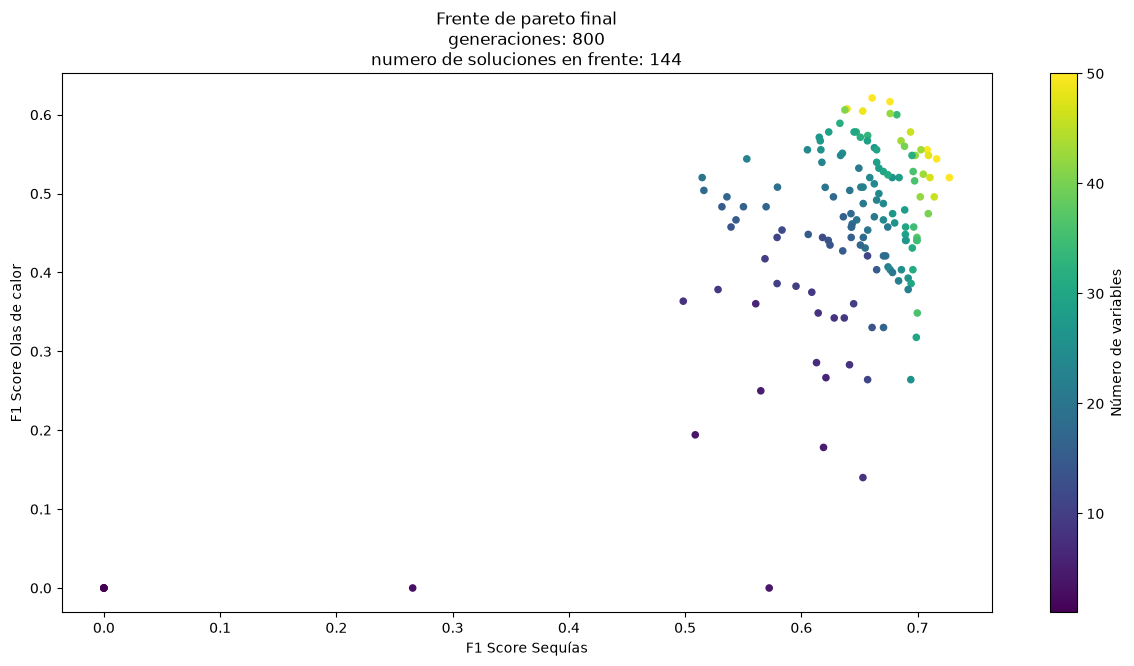

In [5]:
list_dr = []
list_hw = []
list_n_vars = []

for solution in rank0:
    list_dr.append(solution.fitness[0])
    list_hw.append(solution.fitness[1])
    list_n_vars.append(solution.fitness[2])

plt.figure(figsize=(15, 7))
plt.scatter(list_dr, list_hw, c=list_n_vars, cmap='viridis', s=20)
plt.title(f"Frente de pareto final\ngeneraciones: {nsga.generations}\nnumero de soluciones en frente: {len(rank0)}")
plt.colorbar(label='Número de variables')
plt.xlabel("F1 Score Sequías")
plt.ylabel("F1 Score Olas de calor")

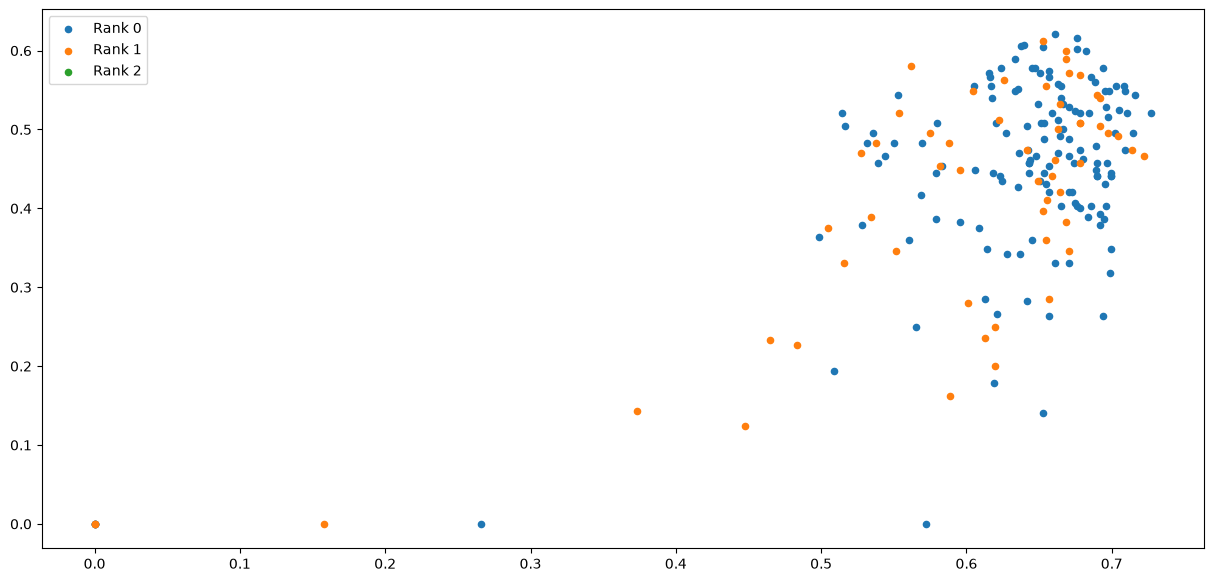

In [6]:
ranks_to_show = [0, 1, 2]
plt.figure(figsize=(15,7))

for rank in ranks_to_show:
    paleto = nsga.get_pareto_front(rank)
    list_dr = []
    list_hw = []
    for solution in paleto:
        list_dr.append(solution.fitness[0])
        list_hw.append(solution.fitness[1])
    plt.scatter(list_dr, list_hw, label=f'Rank {rank}', s=20)

plt.legend()

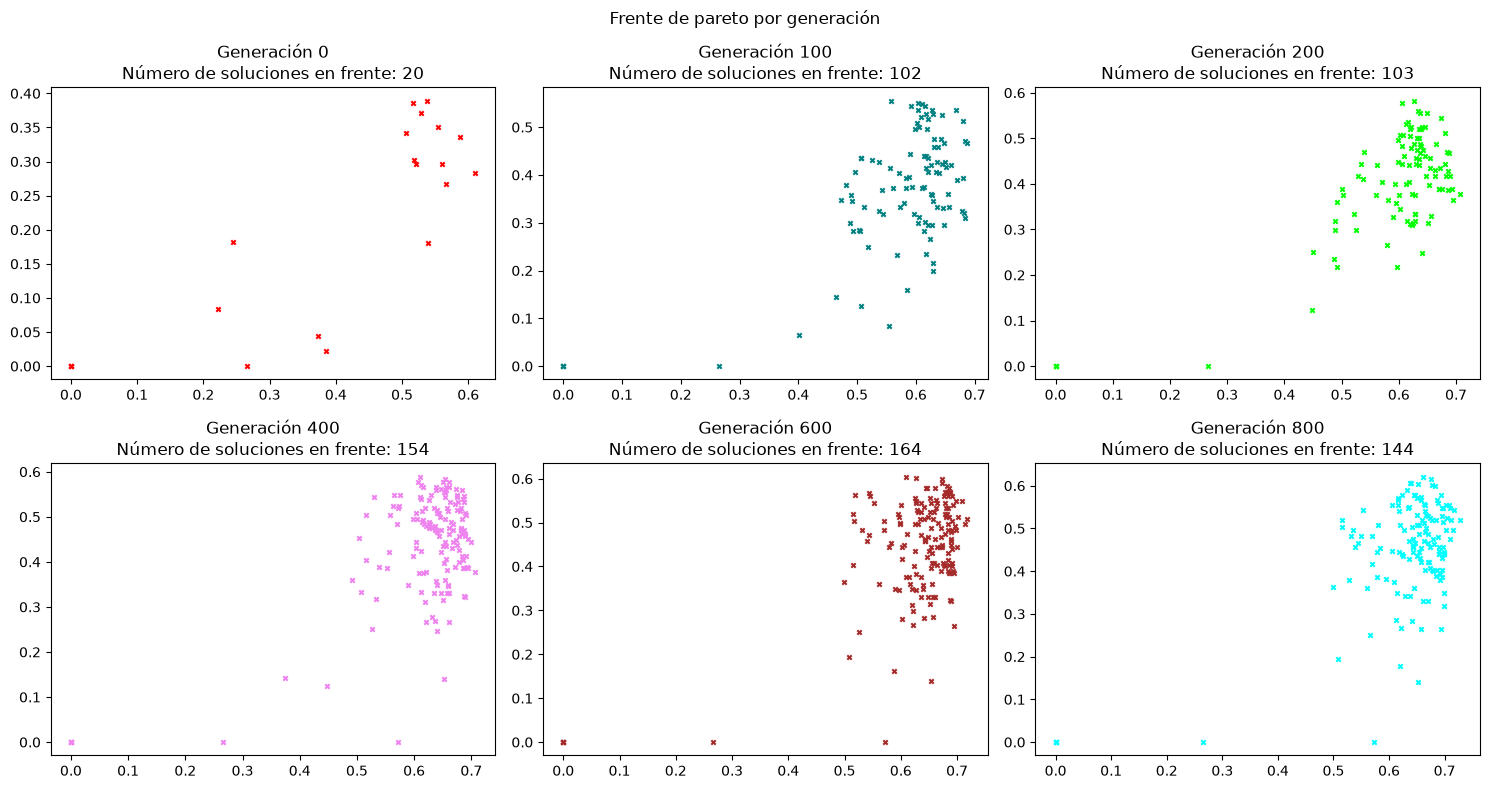

In [9]:
generations = [0, 100, 200, 400, 600, 800]
colors = ["red", "teal", "lime", "violet", "brown", "cyan"]

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
for ax, gen, color in zip(axs, generations, colors):
    history = nsga.pareto_history[gen]
    list_dr = []
    list_hw = []
    
    for posiciones, fitness in history:
        list_dr.append(fitness[0])
        list_hw.append(fitness[1])
        
    ax.scatter(list_dr, list_hw, marker="x", color=color, s=10)
    ax.set_title(f'Generación {gen}\nNúmero de soluciones en frente: {len(nsga.pareto_history[gen])}')
plt.suptitle("Frente de pareto por generación")
plt.tight_layout()

Text(0.5, 1.0, 'Media de variables por generación')

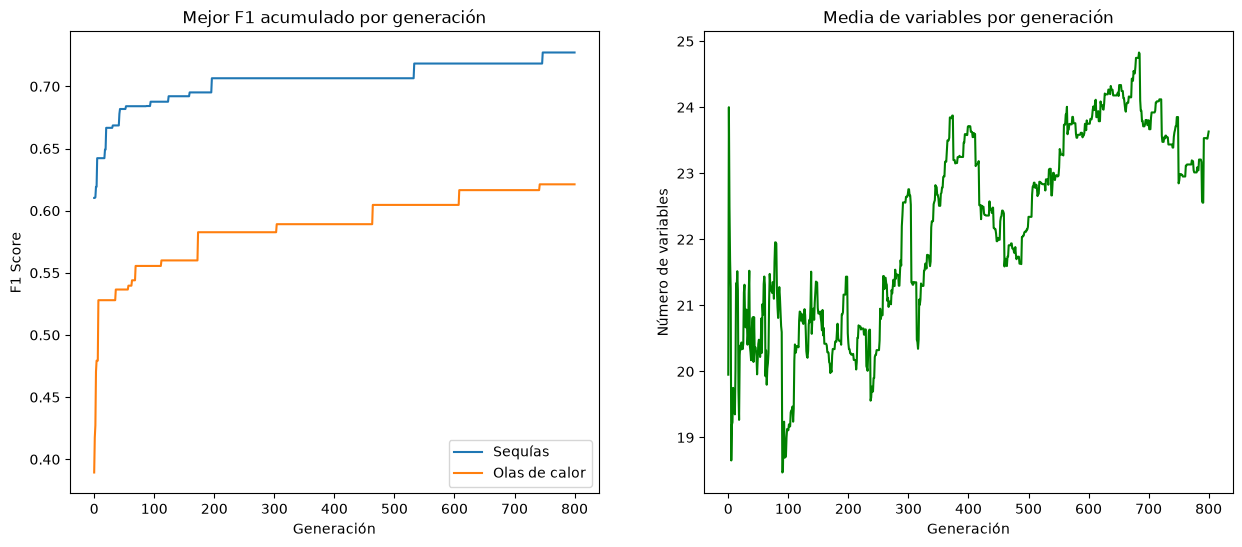

In [8]:
biggest_f1_dr = -1
biggest_f1_hw = -1
biggest_f1_dr_per_gen = []
biggest_f1_hw_per_gen = []
mean_var_per_gen = []

for generation in nsga.pareto_history:
    variables = []
    for positions, fitness in generation:
        if fitness[0] > biggest_f1_dr:
            biggest_f1_dr = fitness[0]
        if fitness[1] > biggest_f1_hw:
            biggest_f1_hw = fitness[1]
        variables.append(fitness[2])
    biggest_f1_dr_per_gen.append(biggest_f1_dr)
    biggest_f1_hw_per_gen.append(biggest_f1_hw)
    mean_var_per_gen.append(sum(variables)/len(variables))

fig, axs = plt.subplots(1, 2, figsize=(15, 6))

axs[0].plot(biggest_f1_dr_per_gen, label='Sequías')
axs[0].plot(biggest_f1_hw_per_gen, label='Olas de calor')
axs[0].set_xlabel('Generación')
axs[0].set_ylabel('F1 Score')
axs[0].set_title('Mejor F1 acumulado por generación')
axs[0].legend()

axs[1].plot(mean_var_per_gen, color='green')
axs[1].set_xlabel('Generación')
axs[1].set_ylabel('Número de variables')
axs[1].set_title('Media de variables por generación')